# African Food Classifier — M2 IABD
### Transfer Learning avec MobileNetV2
**Dataset :** African Foods Datasets (Kaggle)  
**Classes :** Ekwang, Eru, Ndole, Jollof Rice, Palm-nut Soup, Waakye

## 1. Installation & Imports

In [1]:
# Installation des dépendances
!pip install kaggle tensorflow matplotlib seaborn scikit-learn -q

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import json

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU disponible: []


## 2. Téléchargement du Dataset depuis Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("graccy/african-foods-datasets")

print("Path to dataset files:", path)

100%|██████████| 826M/826M [00:12<00:00, 70.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/graccy/african-foods-datasets/versions/1


## 3. Exploration du Dataset

In [6]:
import os

# List the contents of the downloaded dataset path
print(f"Contents of the dataset directory: {os.listdir(path)}")

# Correcting the assumption based on the output: the images are in 'class0'
dataset_base_path = os.path.join(path, 'class0') # Adjusted to 'class0'

if os.path.exists(dataset_base_path):
    print(f"Contents of the 'class0' directory: {os.listdir(dataset_base_path)}")
else:
    print(f"'class0' directory not found at {dataset_base_path}. Please check the actual sub-directory name in the dataset.")

Contents of the dataset directory: ['class0']
Contents of the 'class0' directory: ['train', 'test', 'Fulll dataset', 'val']


## 3. Préparation des données

In [8]:
# Use the dataset_base_path identified during exploration
# Correction: Ensure DATA_DIR points to the 'class0' subdirectory
DATA_DIR_BASE = os.path.join(path, 'class0') # Base path for the dataset splits

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_WARMUP = 10
EPOCHS_FINETUNE = 15

# Data Augmentation pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    # validation_split removed as we have separate train/val directories
)

val_datagen = ImageDataGenerator(
    rescale=1./255
    # validation_split removed as we have separate train/val directories
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR_BASE, 'train'), # Point to the 'train' subdirectory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    # subset='training' not needed when pointing directly to train folder
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR_BASE, 'val'), # Point to the 'val' subdirectory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    # subset='validation' not needed when pointing directly to val folder
    shuffle=False,
    seed=42
)

# Sauvegarde des classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"\n✅ Classes détectées ({num_classes}): {class_names}")
print(f"Images d'entraînement: {train_generator.samples}")
print(f"Images de validation: {val_generator.samples}")

# Sauvegarde du mapping des classes
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print("\n✅ class_names.json sauvegardé")

Found 1161 images belonging to 6 classes.
Found 246 images belonging to 6 classes.

✅ Classes détectées (6): ['ekwang', 'eru', 'jollof-ghana', 'ndole', 'palm-nut-soup', 'waakye']
Images d'entraînement: 1161
Images de validation: 246

✅ class_names.json sauvegardé


/tmp/ipykernel_2500/1058843376.py:14: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2500/1058843376.py:15: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.savefig('dataset_examples.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


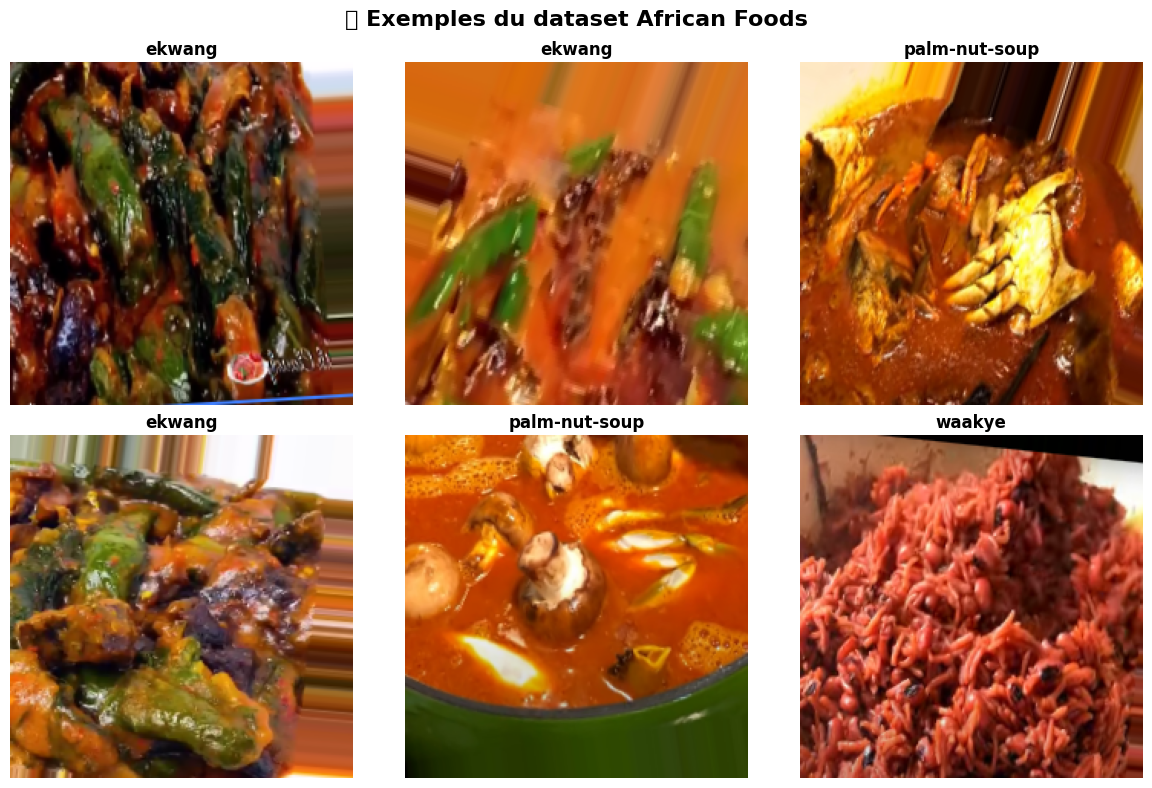

In [11]:
# Visualisation d'exemples du dataset
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

images, labels = next(train_generator)
label_indices = np.argmax(labels, axis=1)

for i in range(min(6, len(images))):
    axes[i].imshow(images[i])
    axes[i].set_title(class_names[label_indices[i]], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('🍽️ Exemples du dataset African Foods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Définition du Modèle (MobileNetV2)

In [12]:
def build_model(num_classes, learning_rate=1e-3):
    """
    Modèle Transfer Learning basé sur MobileNetV2.
    Phase 1 : Base gelée, on entraîne seulement le classifier.
    Phase 2 : Fine-tuning des dernières couches.
    """
    # Base pré-entraînée sur ImageNet
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Geler la base

    # Construction du modèle complet
    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model


model, base_model = build_model(num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,710 (10.01 MB)

 Trainable params: 364,166 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Entraînement du Modèle

### 5.1 Phase de Warm-up (entraînement des couches ajoutées)

In [13]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Phase 1 : Entraînement du classifier (base MobileNetV2 gelée)")
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_WARMUP,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

🚀 Phase 1 : Entraînement du classifier (base MobileNetV2 gelée)
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4660 - loss: 1.5798
Epoch 1: val_accuracy improved from None to 0.73577, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.6434 - loss: 1.0181 - val_accuracy: 0.7358 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8482 - loss: 0.4392
Epoch 2: val_accuracy did not improve from 0.73577
37/37 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8596 - loss: 0.3920 - val_accuracy: 0.7358 - val_loss: 0.6615 - learning_rate: 0.0010
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9043 - loss: 0.2755
Epoch 3: val_accuracy improved from 0.73577 to 0.76423, saving model to best_model_phase1.keras

Epoch 3: finished saving model to best_model_phase1.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 

## 6. Phase 2 — Fine-tuning (dégel des dernières couches)

In [14]:
# Dégel des 30 dernières couches de la base
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompilation avec un LR plus faible
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(f" Phase 2 : Fine-tuning des {30} dernières couches")
history2 = model.fit(
    train_generator,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_generator,
    callbacks=callbacks_ft,
    verbose=1
)

🔧 Phase 2 : Fine-tuning des 30 dernières couches
Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8869 - loss: 0.3525
Epoch 1: val_accuracy improved from None to 0.82927, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8975 - loss: 0.3286 - val_accuracy: 0.8293 - val_loss: 0.5415
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8793 - loss: 0.3661
Epoch 2: val_accuracy did not improve from 0.82927
37/37 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.8906 - loss: 0.3349 - val_accuracy: 0.8293 - val_loss: 0.5570
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8967 - loss: 0.2881
Epoch 3: val_accuracy did not improve from 0.82927
37/37 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - accuracy: 0.8984 - loss: 0.2899 - val_accuracy: 0.8252 - val_loss: 0.5871
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9076 - loss: 0.2778
Epoch 4: val_accuracy

## 7. Évaluation du modèle

/tmp/ipykernel_2500/2478066083.py:28: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2500/2478066083.py:29: UserWarning: Glyph 127869 (\N{FORK AND KNIFE WITH PLATE}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')


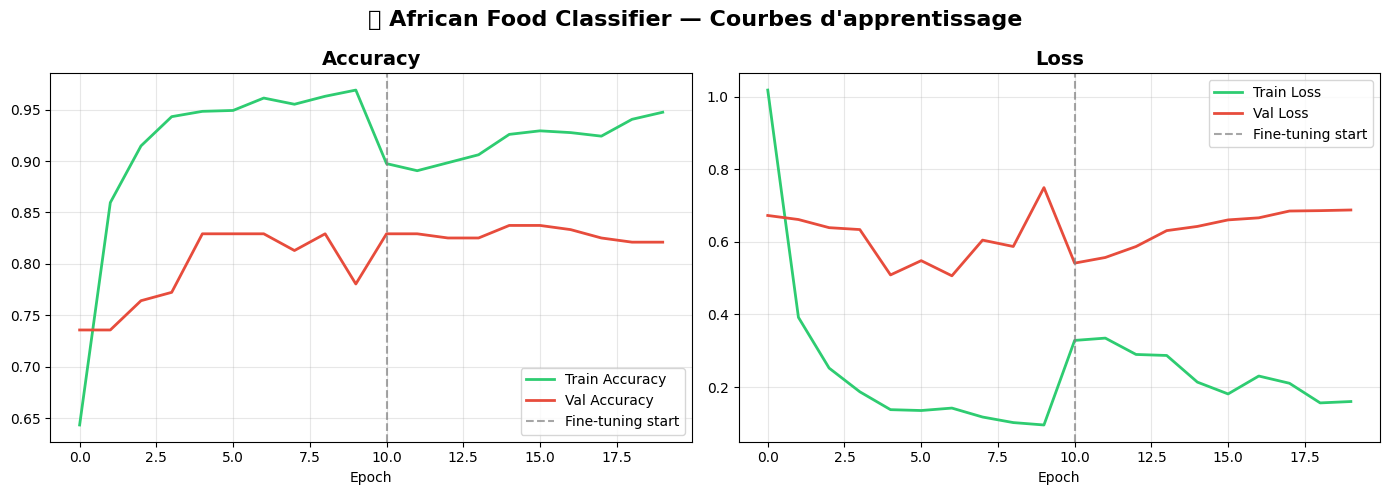

In [15]:
# Courbes d'apprentissage combinées
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    split = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(acc, label='Train Accuracy', color='#2ecc71', linewidth=2)
    ax1.plot(val_acc, label='Val Accuracy', color='#e74c3c', linewidth=2)
    ax1.axvline(x=split, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning start')
    ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(loss, label='Train Loss', color='#2ecc71', linewidth=2)
    ax2.plot(val_loss, label='Val Loss', color='#e74c3c', linewidth=2)
    ax2.axvline(x=split, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning start')
    ax2.set_title('Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(' African Food Classifier — Courbes d\'apprentissage', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, history2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8374 - loss: 0.6425

 Accuracy finale sur validation : 83.74%
   Loss finale : 0.6425
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


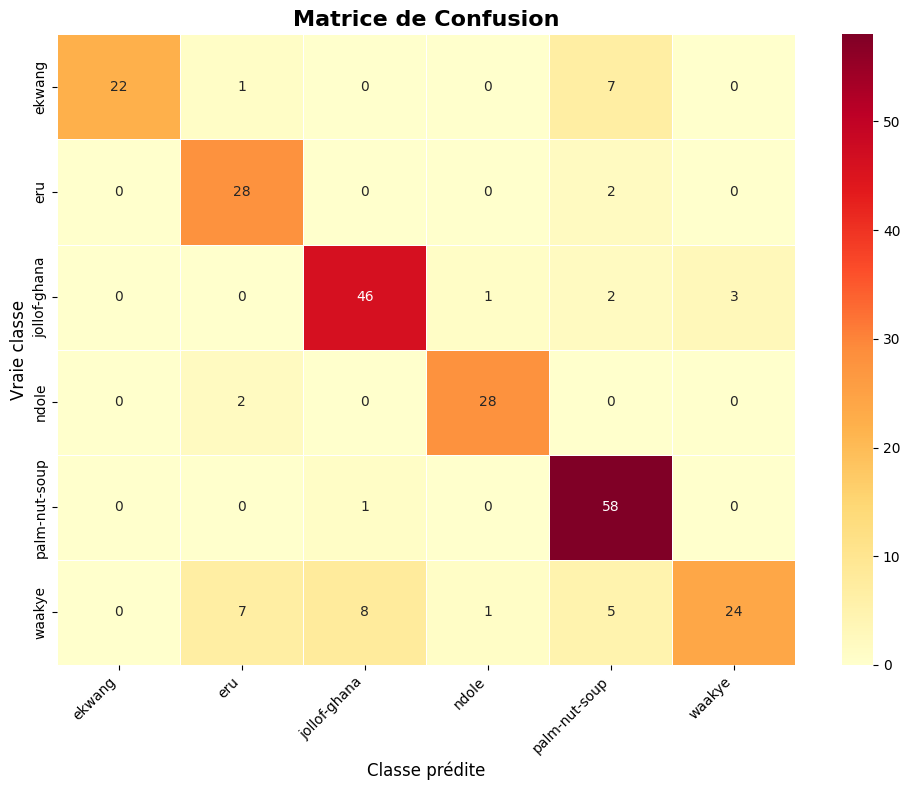


 Rapport de classification :
               precision    recall  f1-score   support

       ekwang       1.00      0.73      0.85        30
          eru       0.74      0.93      0.82        30
 jollof-ghana       0.84      0.88      0.86        52
        ndole       0.93      0.93      0.93        30
palm-nut-soup       0.78      0.98      0.87        59
       waakye       0.89      0.53      0.67        45

     accuracy                           0.84       246
    macro avg       0.86      0.83      0.83       246
 weighted avg       0.85      0.84      0.83       246



In [16]:
# Évaluation finale
val_generator.reset()
loss, accuracy = model.evaluate(val_generator, verbose=1)
print(f"\n Accuracy finale sur validation : {accuracy*100:.2f}%")
print(f"   Loss finale : {loss:.4f}")

# Matrice de confusion
val_generator.reset()
y_pred = model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5
)
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold')
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Rapport de classification :")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

## 8. Sauvegarde du modèle

In [17]:
# Sauvegarde en format .h5 pour Streamlit
model.save('african_food_model.h5')
print("Modèle sauvegardé : african_food_model.h5")

# Vérification de la taille
size_mb = os.path.getsize('african_food_model.h5') / (1024 * 1024)
print(f"   Taille : {size_mb:.1f} MB")

# Vérification du class_names.json
with open('class_names.json', 'r') as f:
    saved_classes = json.load(f)
print(f"Classes sauvegardées : {saved_classes}")

Modèle sauvegardé : african_food_model.h5
   Taille : 24.8 MB
Classes sauvegardées : ['ekwang', 'eru', 'jollof-ghana', 'ndole', 'palm-nut-soup', 'waakye']


In [18]:
# Téléchargement des fichiers nécessaires pour le déploiement
from google.colab import files

print("Téléchargement des fichiers...")
files.download('african_food_model.h5')
files.download('class_names.json')
files.download('training_curves.png')
files.download('confusion_matrix.png')
print("Téléchargements lancés ! Place ces fichiers dans ton dossier projet.")

Téléchargement des fichiers...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargements lancés ! Place ces fichiers dans ton dossier projet.


## 9. Test rapide du modèle

 Prédictions :
  1. ndole: 57.3%
  2. jollof-ghana: 39.4%
  3. eru: 1.5%


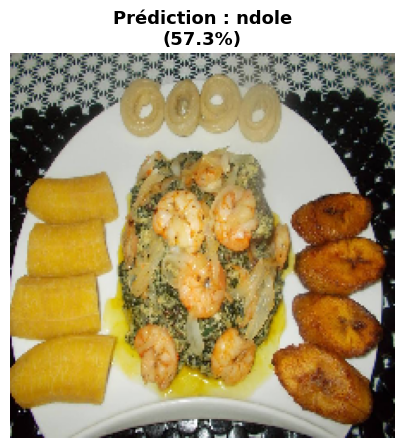

 Décommente la dernière ligne et remplace par un chemin d'image réel pour tester.


In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_food(img_path, model, class_names, top_k=3):
    """Prédit la classe d'un plat africain."""
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = np.argsort(predictions)[::-1][:top_k]

    print(" Prédictions :")
    for i, idx in enumerate(top_indices):
        print(f"  {i+1}. {class_names[idx]}: {predictions[idx]*100:.1f}%")

    # Affichage
    img_display = image.load_img(img_path, target_size=(224, 224))
    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    plt.title(f"Prédiction : {class_names[top_indices[0]]}\n({predictions[top_indices[0]]*100:.1f}%)",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

# Test avec une image du dataset
predict_food('/content/Ndolè_à_la_viande,_morue_et_crevettes.jpg', model, class_names)